# Cleopatra palettes on **real** GIS data

This notebook shows every palette in `cleopatra.palettes` applied to real geospatial rasters (bundled as
NumPy `.npz`, so nothing here is synthetic and no GIS reader is needed):

- a real **digital elevation model** (Rhine basin, 5 km) for the *sequential* and *diverging* palettes, and
- a real **Sentinel-2 land-cover class** raster for the *qualitative* palettes.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import ListedColormap

import cleopatra
from cleopatra.array_glyph import ArrayGlyph
from cleopatra.palettes import available_palettes, get_palette, preview_palettes
print("cleopatra:", cleopatra.__version__, "|", len(available_palettes()), "palettes")

DATA = Path("../data")   # kernel CWD is the notebook's own folder

def load(name):
    """Load an .npz holding a 2-D array and its [xmin, xmax, ymin, ymax] extent."""
    z = np.load(DATA / name)
    return z["array"].astype(float), [float(v) for v in z["extent"]]

dem, dem_ext = load("rhine_dem.npz")
classes, cls_ext = load("sentinel_landcover.npz")
print("DEM:", dem.shape, "elevation range", (np.nanmin(dem).round(1), np.nanmax(dem).round(1)), "m")
print("land-cover classes present:", np.unique(classes[np.isfinite(classes)]).astype(int))

cleopatra: 0.26.1 | 13 palettes
DEM: (125, 93) elevation range (np.float64(-559.4), np.float64(3286.2)) m
land-cover classes present: [1 2 3 4]


## The palette registry at a glance

`preview_palettes()` renders the whole registry as a grouped swatch grid — continuous kinds as smooth ramps,
`qualitative` as discrete swatches.

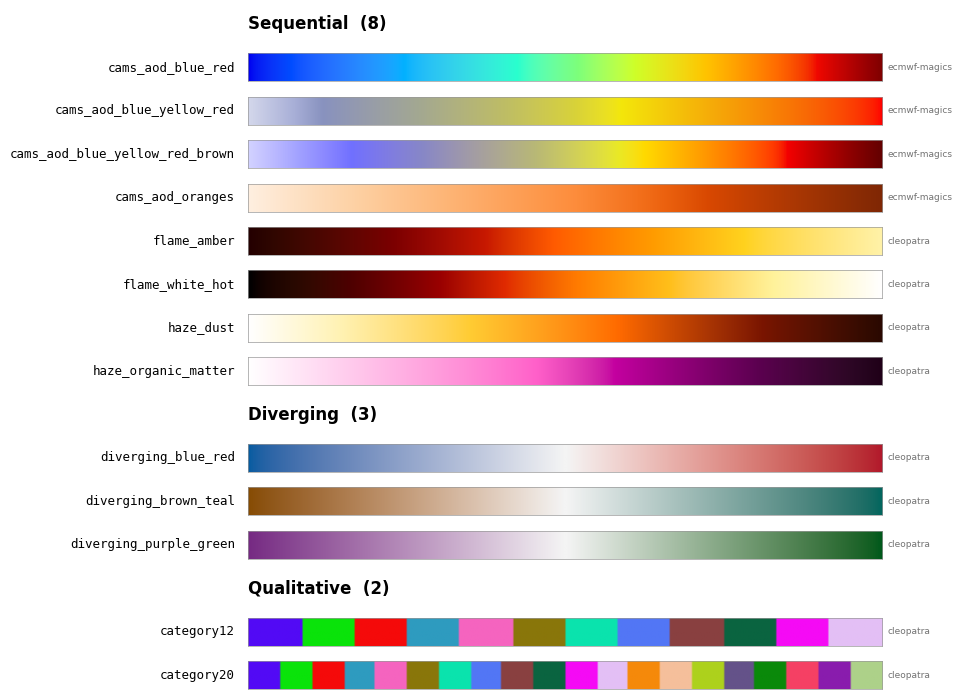

In [2]:
fig = preview_palettes()
fig.set_size_inches(9, 7)
plt.show()

## Sequential & diverging palettes on a real DEM

Each palette is applied through **`ArrayGlyph.plot`**: a plain `Normalize` for sequential ramps, and a
symmetric scale (`center=0`) for diverging ones. The field is the Rhine-basin elevation model.

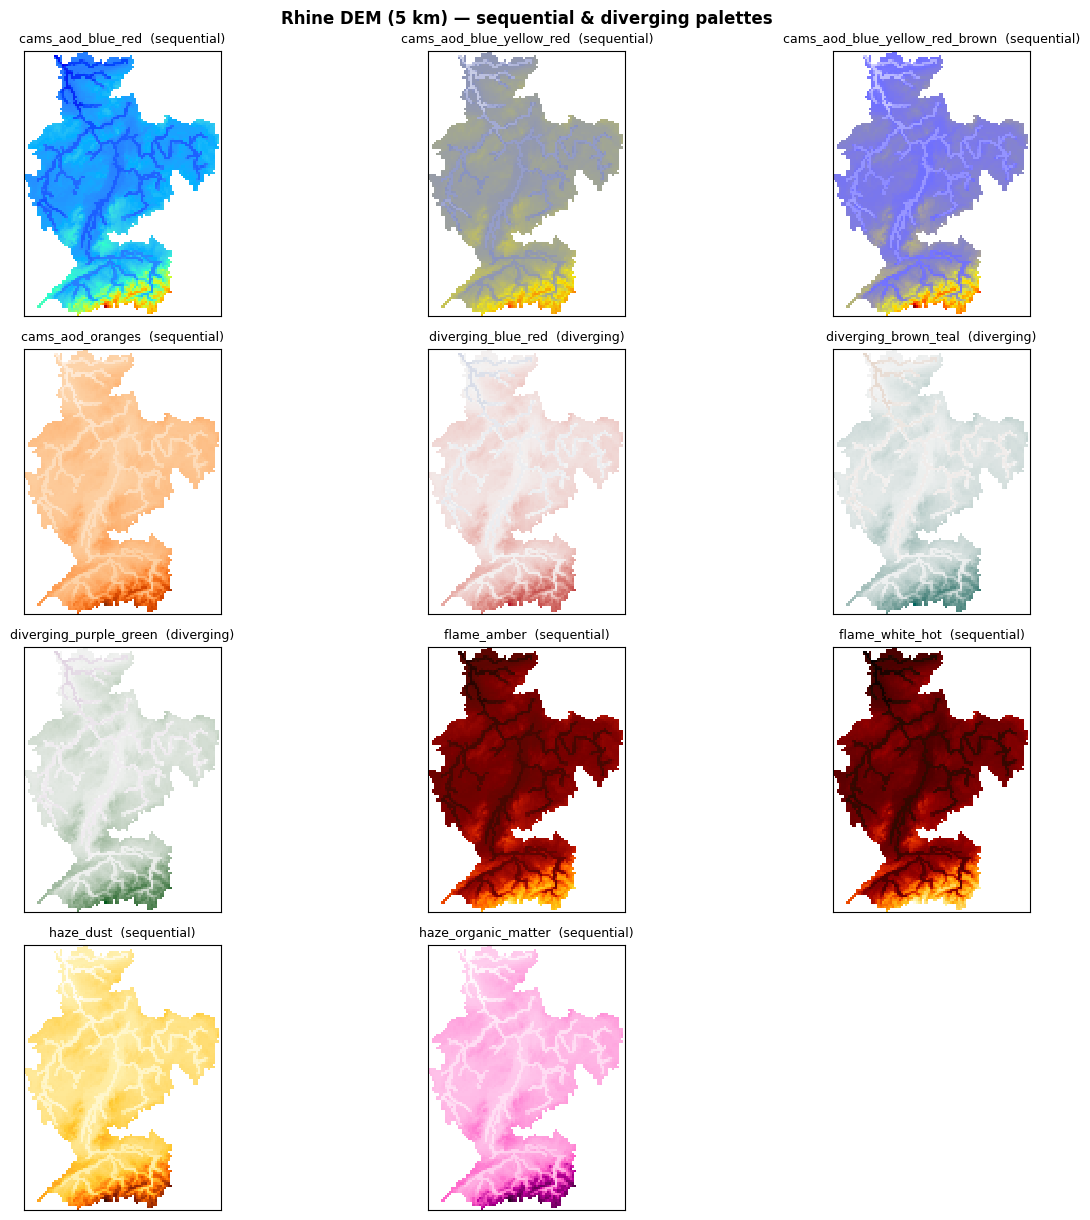

In [3]:
cont = [n for n in available_palettes()
        if get_palette(n).kind.value in ("sequential", "diverging")]
ncol = 3
nrow = int(np.ceil(len(cont) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.1 * nrow))
dext = [dem_ext[0], dem_ext[2], dem_ext[1], dem_ext[3]]   # [xmin, ymin, xmax, ymax]
for ax, name in zip(axes.ravel(), cont):
    p = get_palette(name)
    kw = {"center": 0.0} if p.kind.value == "diverging" else {}
    ArrayGlyph(dem, extent=dext, ax=ax).plot(cmap=p.to_colormap(), add_colorbar=False,
                                             title=f"{name}  ({p.kind.value})", title_size=9, **kw)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes.ravel()[len(cont):]:
    ax.set_visible(False)
fig.suptitle("Rhine DEM (5 km) — sequential & diverging palettes", fontweight="bold")
fig.tight_layout()
plt.show()

## Qualitative palettes on real land-cover classes

The Sentinel-2 raster carries a handful of discrete land-cover classes. A `qualitative` palette maps each
class code to one swatch — `ArrayGlyph.plot` renders it with a `boundary-norm` over a `ListedColormap`, and
the colorbar is relabelled with the class codes.

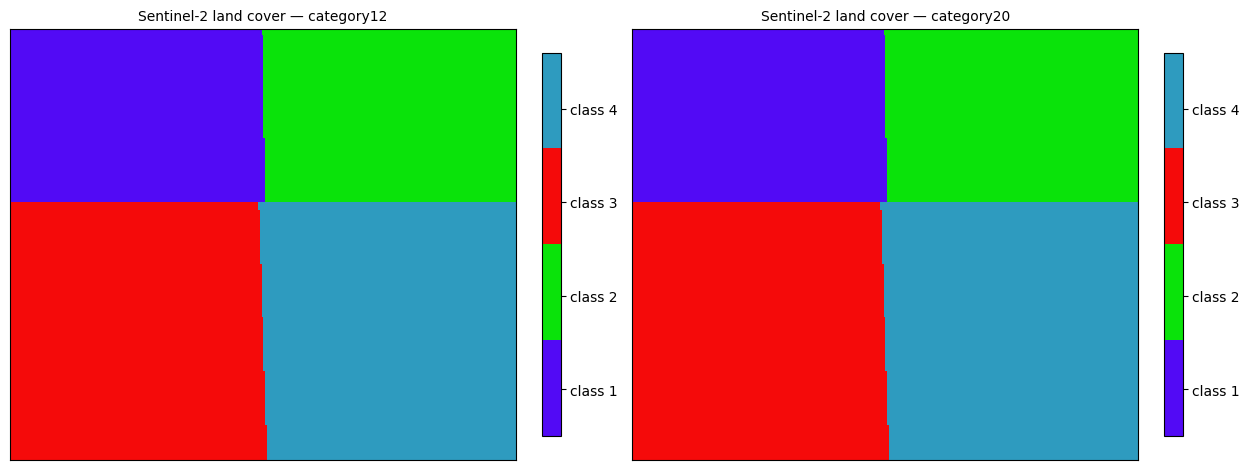

In [4]:
codes = np.unique(classes[np.isfinite(classes)]).astype(int)
k = len(codes)
qual = list(available_palettes("qualitative"))
fig, axes = plt.subplots(1, len(qual), figsize=(6.2 * len(qual), 5.2), constrained_layout=True)
cext = [cls_ext[0], cls_ext[2], cls_ext[1], cls_ext[3]]
remap = {c: i for i, c in enumerate(codes)}                     # class codes -> 0..k-1 for display
idx = np.vectorize(lambda v: remap.get(v, np.nan))(classes)
for ax, name in zip(np.atleast_1d(axes), qual):
    cmap = ListedColormap(list(get_palette(name).colors)[:k])   # k discrete class colours
    glyph = ArrayGlyph(idx, extent=cext, ax=ax)
    glyph.plot(cmap=cmap, vmin=-0.5, vmax=k - 0.5,              # each class code lands on its own colour
               title=f"Sentinel-2 land cover — {name}", title_size=10)
    ax.set_xticks([]); ax.set_yticks([])
    if glyph.cbar is not None:
        glyph.cbar.set_ticks(range(k))
        glyph.cbar.ax.set_yticklabels([f"class {c}" for c in codes])
plt.show()